In [1]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
import python_calamine

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create a dataframe for the months we want to view
month_weekdays = pd.DataFrame({'appointment_month':['2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06']})

# Get holiday dates for Christmas, Easter & bank hols, inc extra Jubilee day Jun '22
holiday_wd = ['2021-08-30', '2021-12-27', '2021-12-28', '2022-01-03', '2022-04-15', '2022-04-18', '2022-05-02', '2022-06-02', '2022-06-03']
holiday_sat = ['2021-12-25', '2022-01-01', '2022-04-16']
holiday_sun = ['2021-12-26', '2022-01-02', '2022-04-17']

# Get the months as a list of strings and a list of datetimes
month_string_list = month_weekdays['appointment_month']
month_list = pd.to_datetime(month_weekdays['appointment_month'])

# Create 2 lists for month 1 and month 2
month_1 = month_list.to_numpy().astype('datetime64[M]')
month_2 = month_1 + np.array([1], dtype='timedelta64[M]')

# Calculate the number of weekdays, Saturdays, Sundays and total days between month 1 and month 2
# Add the calculations as new columns in the dataframe
month_weekdays['weekdays'] = np.busday_count(month_1, month_2, holidays=holiday_wd)
month_weekdays['saturdays'] = np.busday_count(month_1, month_2, weekmask='Sat', holidays=holiday_sat)
month_weekdays['sundays'] = np.busday_count(month_1, month_2, weekmask='Sun', holidays=holiday_sun)
month_weekdays['total_days'] = month_weekdays['weekdays'] + month_weekdays['saturdays'] + month_weekdays['sundays']

# Convert appointment_month to String
month_weekdays['appointment_month'] = month_weekdays['appointment_month'].astype(str)

# View the dataframe
month_weekdays

,appointment_month,weekdays,saturdays,sundays,total_days
0,2021-08,21,4,5,30
1,2021-09,22,4,4,30
2,2021-10,21,5,5,31
3,2021-11,22,4,4,30
4,2021-12,21,3,3,27
5,2022-01,20,4,4,28
6,2022-02,20,4,4,28
7,2022-03,23,4,4,31
8,2022-04,19,4,3,26
9,2022-05,21,4,5,30


In [3]:
# Read in the appointments_regionsl csv file
ar = pd.read_csv('appointments_regional.csv')

# Filter the dataset using the string list of months created earlier
ar_subset=ar[ar['appointment_month'].isin(month_string_list)]

# View the subset dataframe
ar_subset

,region_ons_code,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E40000005,E54000034,2021-08,Attended,GP,Face-to-Face,1 Day,6553
3653,E40000005,E54000034,2021-08,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E40000005,E54000034,2021-08,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E40000005,E54000034,2021-08,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E40000005,E54000034,2021-08,Attended,GP,Face-to-Face,8 to 14 Days,4961
...,...,...,...,...,...,...,...,...
596816,E40000012,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E40000012,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E40000012,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E40000012,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


In [4]:
# Group the subset data by appointment_month
ar_months = ar_subset.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Merge the dataframe with the number of days per month into the subset
ar_final = pd.merge(ar_months, month_weekdays, on='appointment_month', how='outer')

# Get the percent divider as % of 1.2 million appointments (div by 1200000 * 100)
percent_div = 12000

# Calculate the utilisation values and percentages
ar_final['utilisation_weekday'] = (ar_final['count_of_appointments'] / ar_final['weekdays']).round(1)
ar_final['utilisation_inc_saturday'] = (ar_final['count_of_appointments'] / (ar_final['weekdays'] + ar_final['saturdays'])).round(1)
ar_final['utilisation_all'] = (ar_final['count_of_appointments'] / ar_final['total_days']).round(1)
ar_final['weekday_use'] = (ar_final['utilisation_weekday'] / percent_div).round(1)
ar_final['use_inc_saturdays'] = (ar_final['utilisation_inc_saturday'] / percent_div).round(1)
ar_final['use_all_days'] = (ar_final['utilisation_all'] / percent_div).round(1)

#View the dataframe
ar_final

,appointment_month,count_of_appointments,weekdays,saturdays,sundays,total_days,utilisation_weekday,utilisation_inc_saturday,utilisation_all,weekday_use,use_inc_saturdays,use_all_days
0,2021-08,23852171,21,4,5,30,1135817.7,954086.8,795072.4,94.7,79.5,66.3
1,2021-09,28522501,22,4,4,30,1296477.3,1097019.3,950750.0,108.0,91.4,79.2
2,2021-10,30303834,21,5,5,31,1443039.7,1165532.1,977543.0,120.3,97.1,81.5
3,2021-11,30405070,22,4,4,30,1382048.6,1169425.8,1013502.3,115.2,97.5,84.5
4,2021-12,25140776,21,3,3,27,1197179.8,1047532.3,931139.9,99.8,87.3,77.6
5,2022-01,25635474,20,4,4,28,1281773.7,1068144.8,915552.6,106.8,89.0,76.3
6,2022-02,25355260,20,4,4,28,1267763.0,1056469.2,905545.0,105.6,88.0,75.5
7,2022-03,29595038,23,4,4,31,1286740.8,1096112.5,954678.6,107.2,91.3,79.6
8,2022-04,23913060,19,4,3,26,1258582.1,1039698.3,919733.1,104.9,86.6,76.6
9,2022-05,27495508,21,4,5,30,1309309.9,1099820.3,916516.9,109.1,91.7,76.4


In [5]:
# Melt dataframe for multi line plot
ar_melt = ar_final.melt(id_vars='appointment_month', \
                                 value_vars=['weekday_use', 'use_inc_saturdays', 'use_all_days'], \
                                 var_name='Month', \
                                 value_name='Utilisation')


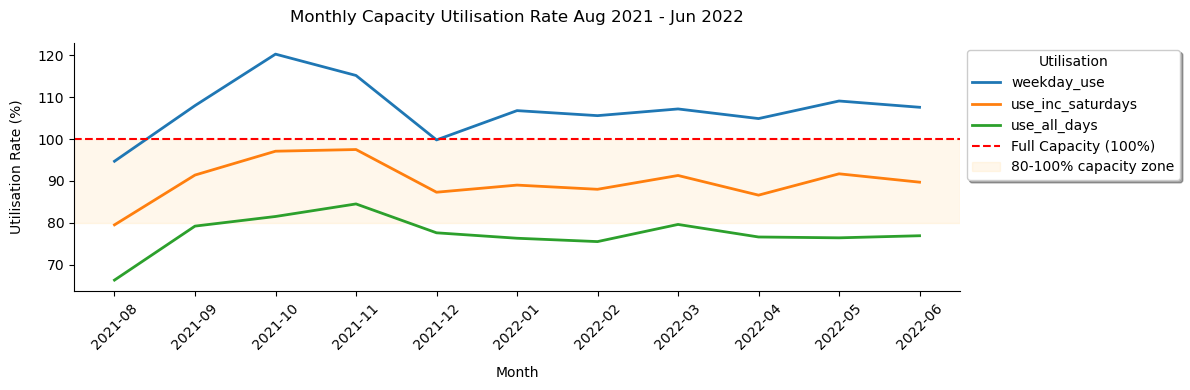

In [6]:
# Create the line plot
fig, ax = plt.subplots(figsize=(12, 4))

ax = sns.lineplot(x = 'appointment_month',
                  y = 'Utilisation',
                  hue = 'Month',
                  data=ar_melt,
                  linewidth=2, 
                  errorbar=None)

# Add the 100% capacity line
ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label= 'Full Capacity (100%)')

# Add a coloured span black denoting 80% to 100% capacity
ax.axhspan(80, 100, alpha=0.08, color='orange', label='80-100% capacity zone')

# Set plot title and labels
ax.set_title('Monthly Capacity Utilisation Rate Aug 2021 - Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
plt.xticks(rotation=45)

#Move the legend to the side of the graph and add a title
plt.legend(title='Utilisation', fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
sns.despine()
plt.show()

In [38]:
#nc = pd.read_excel('national_categories.xlsx', sheet_name='national_categories', engine='calamine')

slp_icbs = pd.read_csv('icb_location_patients_appointments_Dec21_to_Jun22.csv', usecols=['icb_ons_code', 'icb'])

slp_icb_grp = slp_icbs.groupby(['icb_ons_code', 'icb']).count().reset_index()
nc_icbs = nc.groupby('icb_ons_code').sum('count_of_appointments').sort_values(by='count_of_appointments', ascending=False).reset_index()

nc_top_icbs = pd.merge(nc_icbs, slp_icb_grp, on='icb_ons_code')

nc_top_icbs

,icb_ons_code,count_of_appointments,icb
0,E54000050,16882235,North East and North Cumbria
1,E54000054,14358371,West Yorkshire
2,E54000057,13857900,Greater Manchester
3,E54000008,13250311,Cheshire and Merseyside
4,E54000027,12142390,North West London
5,E54000029,9588891,North East London
6,E54000032,9286167,Kent and Medway
7,E54000042,9210625,Hampshire and Isle Of Wight
8,E54000051,9125945,Humber and North Yorkshire
9,E54000053,8929398,Sussex


In [41]:
# Get the national categories in order of most appointments
nc_top_categories = nc.groupby('national_category').sum('count_of_appointments').sort_values(by='count_of_appointments', ascending=False).reset_index()

# Get the ICB Names and group them
slp_icbs = pd.read_csv('icb_location_patients_appointments_Dec21_to_Jun22.csv', usecols=['icb_ons_code', 'icb'])
slp_icb_grp = slp_icbs.groupby(['icb_ons_code', 'icb']).count().reset_index()

# Get the ICB's in order of most appointments
nc_icbs = nc.groupby('icb_ons_code').sum('count_of_appointments').sort_values(by='count_of_appointments', ascending=False).reset_index()

# Merge the national categories data with the ICB names list
nc_top_icbs = pd.merge(nc_icbs, slp_icb_grp, on='icb_ons_code')
nc_df = pd.merge(nc, slp_icb_grp, on='icb_ons_code')

# Put the top 4 categories into a list
top_cats = nc_top_categories['national_category'].head(4).tolist()
top_cats

# Put the top 5 ICB's into a list
top_icbs = nc_top_icbs['icb'].head(5).tolist()

# Filter nc to show only the top ICB's and Categories
top_nc_monthly = nc_df[(nc_df['icb'].isin(top_icbs)) & (nc_df['national_category'].isin(top_cats))] \
    .groupby(['icb', 'appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

# Calculate percentages within each ICB per month 
monthly_total = top_nc_monthly.groupby(['icb', 'appointment_month']) \
    ['count_of_appointments'].transform('sum')

top_nc_monthly['percentage'] = (top_nc_monthly['count_of_appointments'] / monthly_total * 100).round(1)

top_nc_monthly

,icb,appointment_month,national_category,count_of_appointments,percentage
0,Cheshire and Merseyside,2021-08,Clinical Triage,223531,27.7
1,Cheshire and Merseyside,2021-08,General Consultation Acute,186637,23.1
2,Cheshire and Merseyside,2021-08,General Consultation Routine,333833,41.3
3,Cheshire and Merseyside,2021-08,Planned Clinics,64225,7.9
4,Cheshire and Merseyside,2021-09,Clinical Triage,248313,26.0
...,...,...,...,...,...
215,West Yorkshire,2022-05,Planned Clinics,160302,16.2
216,West Yorkshire,2022-06,Clinical Triage,146927,15.7
217,West Yorkshire,2022-06,General Consultation Acute,230290,24.6
218,West Yorkshire,2022-06,General Consultation Routine,406029,43.4


In [43]:
nc_df

,appointment_date,region_ons_code,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,icb
0,2021-08-02,E40000012,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,North East and North Cumbria
1,2021-08-02,E40000012,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,North East and North Cumbria
2,2021-08-02,E40000012,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,North East and North Cumbria
3,2021-08-02,E40000012,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,North East and North Cumbria
4,2021-08-02,E40000012,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,North East and North Cumbria
...,...,...,...,...,...,...,...,...,...,...
817389,2022-06-30,E40000012,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06,West Yorkshire
817390,2022-06-30,E40000012,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06,West Yorkshire
817391,2022-06-30,E40000012,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06,West Yorkshire
817392,2022-06-30,E40000012,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06,West Yorkshire


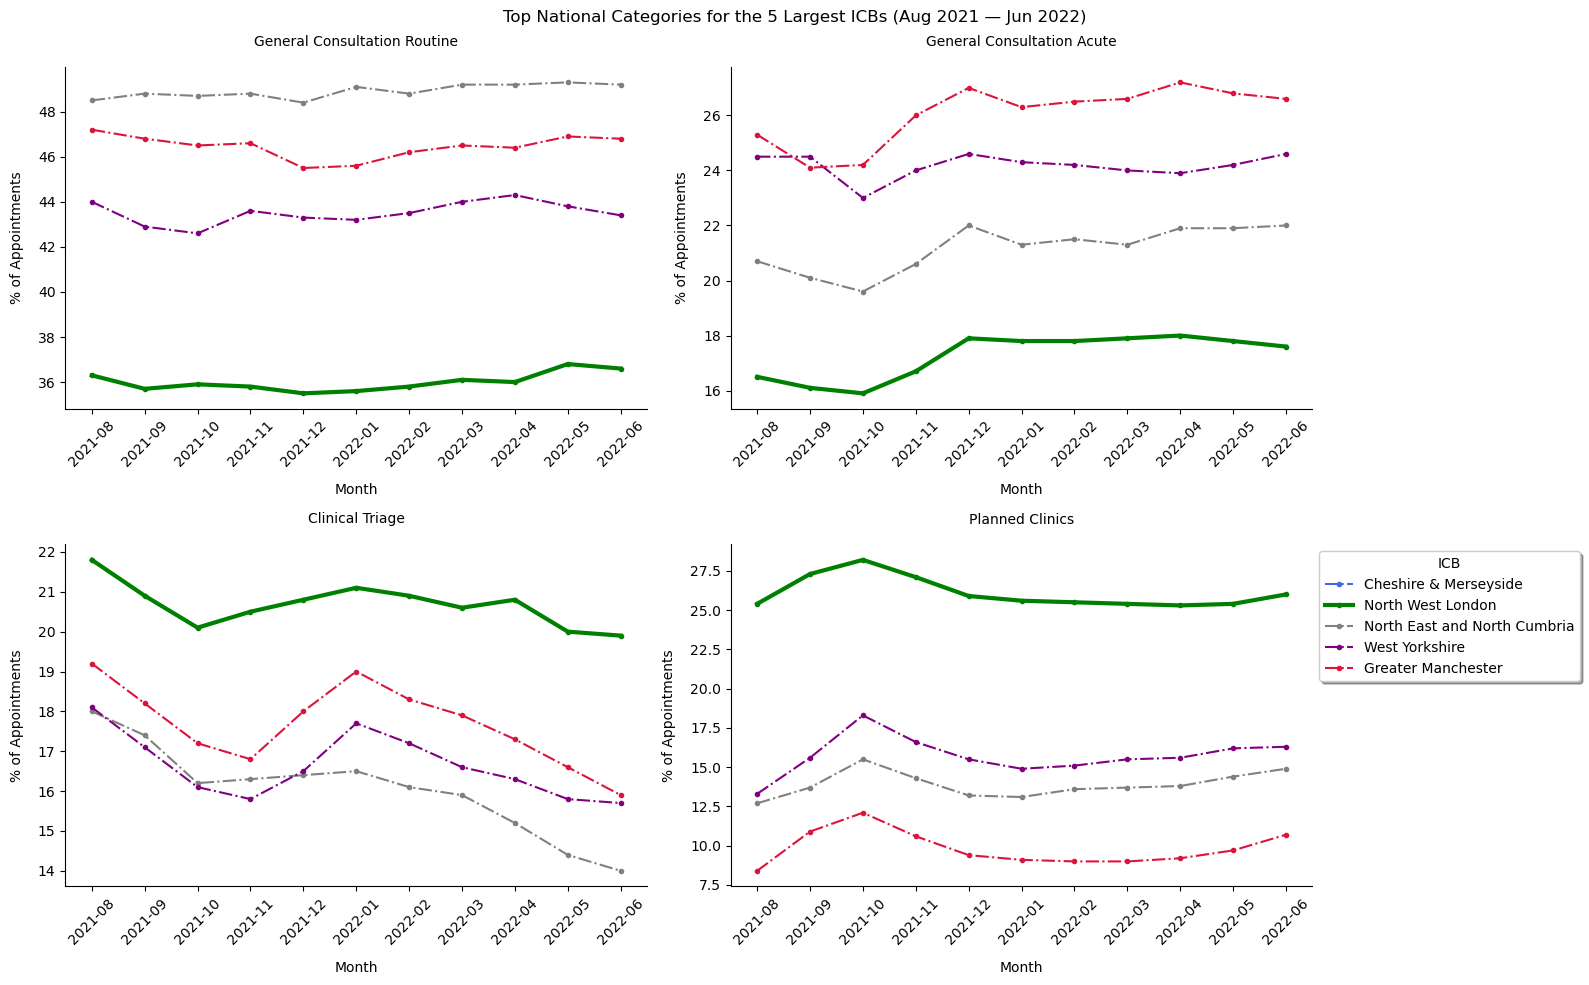

In [45]:
# Plot one chart per category
colours = {
    'Cheshire & Merseyside': 'royalblue',
    'North West London': 'green',
    'North East and North Cumbria': 'gray',
    'West Yorkshire': 'purple',
    'Greater Manchester': 'crimson'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10)) 
axes = axes.flatten()

for idx, category in enumerate(top_cats):
    ax = axes[idx]
    cat_data = top_nc_monthly[top_nc_monthly['national_category'] == category]
   
    for icb, colour in colours.items():
        subset = cat_data[cat_data['icb'] == icb]
        lw = 3 if icb == 'North West London' else 1.5
        ls = '-' if icb == 'North West London' else '-.'
        ax.plot(subset['appointment_month'],
                subset['percentage'],
                color=colour, 
                linewidth=lw,
                linestyle=ls,
                marker='o', 
                markersize=3,
                label=icb)
   
    ax.set_title(category, pad=15, fontsize=10)
    ax.set_xlabel('Month', labelpad=10)
    ax.set_ylabel('% of Appointments', labelpad=10)
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

plt.suptitle('Top National Categories for the 5 Largest ICBs (Aug 2021 — Jun 2022)', fontsize=12)
plt.legend(title='ICB', fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()